In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [2]:
# load
X =np.load('data/f8/updated_inputs.npy')
y=np.load('data/f8/updated_outputs.npy')

In [3]:
# Normalization
y_mean_val = np.mean(y)
y_std_val  = np.std(y)
y_norm    = (y - y_mean_val) / y_std_val if y_std_val > 0 else y

In [4]:
# The best
best_f = np.max(y_norm)
best_idx = np.argmax(y_norm)
print(f"Current best: X = {X[best_idx]}, y_norm = {best_f:.4f}")
print('y_best=', y[best_idx])

Current best: X = [0.253633 0.173318 0.166264 0.17144  0.837102 0.879041 0.189491 0.861892], y_norm = 1.9643
y_best= 9.7964051877986


In [5]:
# Grid for evaluation
from scipy.stats import qmc

dim=8
n_grid = 5000 
sampler = qmc.LatinHypercube(d=dim, seed=42)
sample = sampler.random(n=n_grid)

# Escalar cada dimensión al rango real de X
l_bounds = X.min(axis=0)  
u_bounds = X.max(axis=0)  
x_grid_d = qmc.scale(sample, l_bounds, u_bounds)

In [6]:
###  New adquisition Function EI (same GP)

In [7]:
# EI
def expected_improvement(mean, std, best_f, xi=0.01):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

In [8]:
# GP model: find optimal alpha
noise_assumption = 1.e-5
distances = pdist(X, metric='euclidean') # compute mean distance between data
Alpha=[]
Mean=[]
STD=[]
for alpha in np.linspace(0.1, 3, 30):
    rbf_lengthscale  = alpha*distances.mean()#alpha times mean distance

    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    model.fit(X, y_norm)

    # GP prediction ---
    post_mean, post_std = model.predict(x_grid_d, return_std=True)

    ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)
    idx_next  = np.argmax(ei_values)# simple grid
    x_next    = x_grid_d[idx_next]
    Alpha.append(alpha)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

Alpha for max mean= 0.7


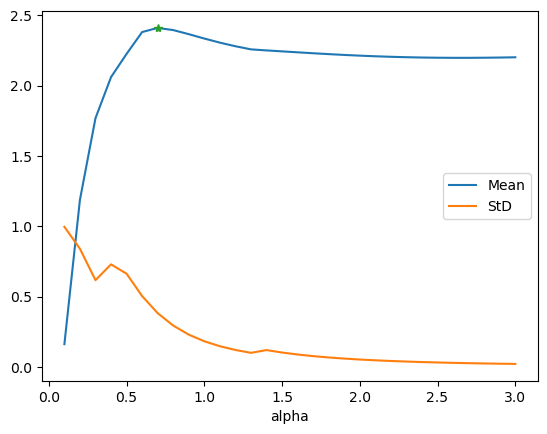

In [9]:
# identify optimal alpha
id_max = np.argmax(Mean)
plt.plot(Alpha,Mean, label='Mean')
plt.plot(Alpha,STD, label='StD')
plt.plot(Alpha[id_max], Mean[id_max], marker='*')
plt.xlabel('alpha')
plt.legend()
print('Alpha for max mean=',Alpha[id_max])

In [10]:
print(f"Best query from (EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}, x4={x_next[3]:.8f}, x5={x_next[4]:.8f},  x6={x_next[5]:.8f}, x7={x_next[6]:.8f}, x8={x_next[7]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

Best query from (EI): x1=0.05615600, x2=0.42320693, x3=0.12346294, x4=0.16243489, x5=0.92616578,  x6=0.27067942, x7=0.25336608, x8=0.53396093
mean next= 2.2016262422430373
std next= 0.02199133367795218


In [11]:
# Write output file
import os
folder = 'results'
filename = 'output_F8.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next[0]:.6f} {x_next[1]:.6f} {x_next[2]:.6f} {x_next[3]:.6f} {x_next[4]:.6f} {x_next[5]:.6f} {x_next[6]:.6f} {x_next[7]:.6f}\n")